## Support Vector Machine

## 1. Setup

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from model_wrappers import ThresholdedClassifier, OutlierCapper
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

FINAL_K = 30  # number of features selected — matches the shared value used in Preprocess_expanded.ipynb

In [2]:
try:
    X_train_raw = joblib.load("X_train_raw.pkl")
    X_test_raw = joblib.load("X_test_raw.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
    print("X_test_raw :", X_test_raw.shape, "y_test :", y_test.shape)

Loaded successfully
X_train_raw: (3996, 42) y_train: (3996,)
X_test_raw : (1000, 42) y_test : (1000,)


## 1.2 Results Log
**All exploratory/comparison entries use cross-validation on training data only** (`log_cv`) — the test set is not touched until the single \"Final Model Declaration\" section at the end (`log_test`), used exactly once.

In [3]:
results_log = []
candidate_models = {}

def log_cv(name, acc, model=None):
    """Log a cross-validated (train-only) accuracy estimate."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "CV (train only)"})
    if model is not None:
        candidate_models[name] = model
    print(f"[Logged - CV] {name}: {acc:.4f}")
    return acc

def log_test(name, y_true, y_pred):
    """Log a genuine held-out test accuracy. Reserved for the FINAL declared model only."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "TEST (final, touched once)"})
    print(f"[Logged - TEST] {name}: {acc:.4f}")
    return acc

## 2. Baseline Model
Default `SVC` hyperparameters, wrapped in a `Pipeline` with feature selection and scaling.

In [4]:
baseline_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42, probability=True))
])

try:
    cv_scores = cross_val_score(baseline_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during baseline cross-validation: {e}")
else:
    print("Baseline 10-fold CV Accuracy:", cv_scores.mean())
    log_cv("Baseline (default SVC)", cv_scores.mean(), model=baseline_pipeline)

Baseline 10-fold CV Accuracy: 0.8002976190476192
[Logged - CV] Baseline (default SVC): 0.8003


## 3. Hyperparameter Tuning 
Grid Search now tunes the full `Pipeline` together, so `SelectKBest` and `StandardScaler` are refit independently inside every one of the 10 folds.

In [5]:
pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42, probability=True))
])

param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__gamma": ["scale", "auto"],
}

try:
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=10,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train_raw, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_pipeline = grid_search.best_estimator_
    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Accuracy:", grid_search.best_score_)
    log_cv("Grid Search Tuned", grid_search.best_score_, model=best_pipeline)

    best_parameters = pd.DataFrame({
        "Parameter": grid_search.best_params_.keys(),
        "Best Value": grid_search.best_params_.values()
    })

Best Parameters: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}
Best CV Accuracy: 0.8007932330827069
[Logged - CV] Grid Search Tuned: 0.8008


In [6]:
best_parameters

,Parameter,Best Value
0,clf__C,1
1,clf__gamma,scale
2,clf__kernel,poly


## 4. Training-Set Sanity Check \nThe real generalization gap is confirmed once, honestly, in the Final Model Declaration section.

In [7]:
try:
    train_accuracy = best_pipeline.score(X_train_raw, y_train)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating training accuracy: {e}")
else:
    print("Training Accuracy (best pipeline):", train_accuracy)

Training Accuracy (best pipeline): 0.8445945945945946


## 5. Model Stability — 10-Fold Cross-Validation & Accuracy vs. C
Fold-by-fold view of the tuned pipeline's CV accuracy, plus an Accuracy vs. C sweep — each C value is wrapped in its own fresh `Pipeline`, refitting selection/scaling per fold for every C tested. \n\n**A note on \"loss curves\" for SVM:** `SVC` doesn't expose per-iteration loss the way `MLPClassifier` does. The Accuracy vs. C plot is the closest honest equivalent — `C` controls the same margin-vs-error tradeoff the hinge-loss objective balances internally.

[0.79       0.805      0.8        0.83       0.8125     0.7975
 0.81453634 0.79448622 0.78696742 0.77694236]
Average Accuracy: 0.8007932330827069
Standard Deviation: 0.014575383248752323


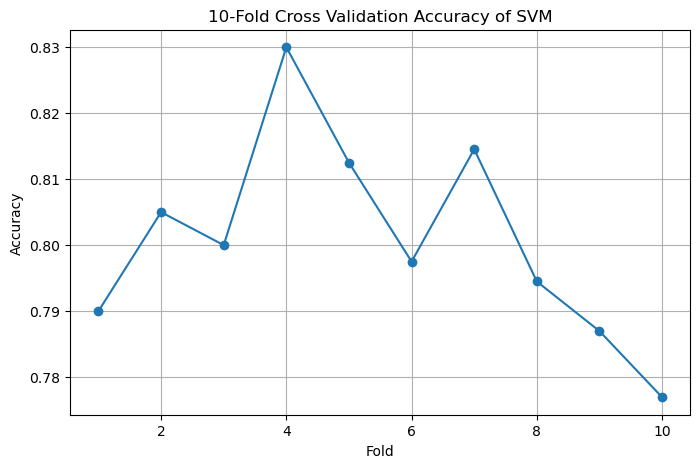

In [8]:
try:
    scores = cross_val_score(best_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print(scores)
    print("Average Accuracy:", scores.mean())
    print("Standard Deviation:", scores.std())

    cv_results = pd.DataFrame({
        "Fold": range(1, 11),
        "Accuracy": scores
    })

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 11), scores, marker='o')
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.title("10-Fold Cross Validation Accuracy of SVM")
    plt.grid(True)
    plt.show()

In [9]:
cv_results

,Fold,Accuracy
0,1,0.790000
1,2,0.805000
2,3,0.800000
3,4,0.830000
4,5,0.812500
5,6,0.797500
6,7,0.814536
7,8,0.794486
8,9,0.786967
9,10,0.776942


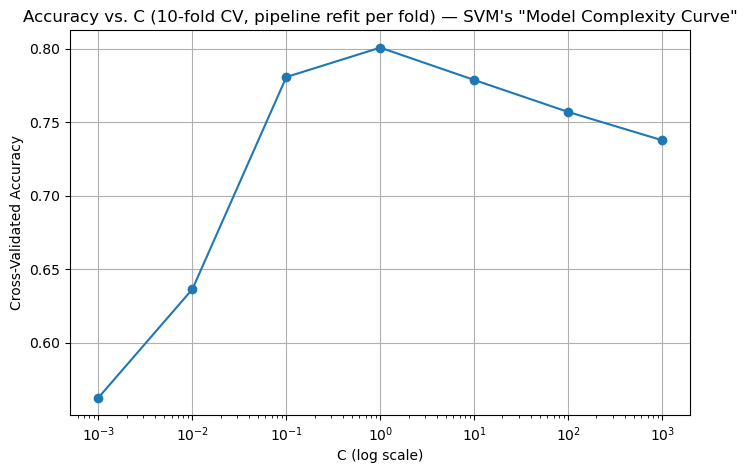

In [10]:
best_kernel = grid_search.best_params_['clf__kernel']
best_gamma = grid_search.best_params_['clf__gamma']

C_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
C_scores = []

try:
    for c_val in C_range:
        temp_pipeline = Pipeline([
            ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
            ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
            ("scaler", StandardScaler()),
            ("clf", SVC(C=c_val, kernel=best_kernel, gamma=best_gamma, random_state=42))
        ])
        cv_result = cross_val_score(temp_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
        C_scores.append(cv_result.mean())
except (ValueError, RuntimeError) as e:
    print(f"Error during C sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(C_range, C_scores, marker="o")
    plt.xscale("log")
    plt.title("Accuracy vs. C (10-fold CV, pipeline refit per fold) — SVM's \"Model Complexity Curve\"")
    plt.xlabel("C (log scale)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## 6. Decision Threshold Optimization (Youden's J Statistic) 
The optimal threshold is found using **out-of-fold predicted probabilities on the training set only** — the test set plays no role in choosing it.

In [11]:
try:
    y_train_probs = cross_val_predict(best_pipeline, X_train_raw, y_train, cv=10, method="predict_proba")[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_train_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_train_pred_optimal = (y_train_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    cv_thresholded_acc = accuracy_score(y_train, y_train_pred_optimal)
    print("Out-of-fold accuracy at this threshold (train, CV-based):", cv_thresholded_acc)
    log_cv("Grid Search + Youden's J", cv_thresholded_acc, model=(best_pipeline, best_threshold))

Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): 0.5815
Youden's J at this threshold: 0.5980
Out-of-fold accuracy at this threshold (train, CV-based): 0.80005005005005
[Logged - CV] Grid Search + Youden's J: 0.8001


## 6.2 Balanced Class Weighting 
SVM's model-specific \"extra formula\": `class_weight='balanced'` reweights each class's contribution to the margin optimization using: $$w_c = \\frac{n_{samples}}{n_{classes} \\times n_c}$$ Evaluated via 10-fold CV on training data only, same as every other candidate.

In [12]:
balanced_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", SVC(
        C=grid_search.best_params_['clf__C'],
        kernel=grid_search.best_params_['clf__kernel'],
        gamma=grid_search.best_params_['clf__gamma'],
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

try:
    balanced_cv_scores = cross_val_score(balanced_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during balanced SVM cross-validation: {e}")
else:
    print("Balanced Class Weighting 10-fold CV Accuracy:", balanced_cv_scores.mean())
    log_cv("Balanced Class Weighting", balanced_cv_scores.mean(), model=balanced_pipeline)

Balanced Class Weighting 10-fold CV Accuracy: 0.7947919799498746
[Logged - CV] Balanced Class Weighting: 0.7948


## 6.3 Probability Calibration

SVM's `predict_proba()` is a special case worth knowing about: it isn't a natural byproduct of the 
algorithm (SVM's core math produces a decision boundary, not a probability) — scikit-learn derives it 
internally via Platt scaling, an approximation that can itself be imperfect. Adding an explicit 
`CalibratedClassifierCV` layer on top gives a second, often more reliable calibration pass. Evaluated 
via 10-fold CV on training data only, same as every other candidate.

In [13]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",  # good default for smaller datasets; try "isotonic" if you have a lot of data
    cv=5                # internal CV used to fit the calibration mapping itself
)

try:
    calibrated_cv_scores = cross_val_score(calibrated_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during calibration cross-validation: {e}")
else:
    print("Calibrated Model 10-fold CV Accuracy:", calibrated_cv_scores.mean())
    log_cv("Probability Calibration (sigmoid)", calibrated_cv_scores.mean(), model=calibrated_pipeline)

Calibrated Model 10-fold CV Accuracy: 0.7957926065162907
[Logged - CV] Probability Calibration (sigmoid): 0.7958


## 7. Additional Diagnostics — Kernel Comparison & Support Vectors 
Kernel comparison now uses cross-validation on training data only (previously it repeatedly predicted on the test set for each kernel, which counted as multiple test touches).

In [14]:
kernels = ["linear", "rbf", "poly"]
kernel_result = []

for kernel in kernels:
    temp_pipeline = Pipeline([
        ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
        ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel=kernel, random_state=42))
    ])
    try:
        cv_result = cross_val_score(temp_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
    except (ValueError, RuntimeError) as e:
        print(f"Error training kernel '{kernel}': {e}")
        continue
    acc = cv_result.mean()
    kernel_result.append({"Kernel": kernel, "CV Accuracy": acc})
    log_cv(f"Kernel Comparison: {kernel}", acc)

kernel_result = pd.DataFrame(kernel_result)
print(kernel_result)

# support vector count — from the tuned pipeline, fit on the full training set (no test touch)
try:
    best_pipeline.fit(X_train_raw, y_train)
    print("\nSupport Vectors for Each Class:", best_pipeline.named_steps["clf"].n_support_)
except AttributeError as e:
    print(f"Support vector info not available: {e}")

[Logged - CV] Kernel Comparison: linear: 0.7738
[Logged - CV] Kernel Comparison: rbf: 0.8003
[Logged - CV] Kernel Comparison: poly: 0.8008
   Kernel  CV Accuracy
0  linear     0.773763
1     rbf     0.800298
2    poly     0.800793

Support Vectors for Each Class: [1051 1106]


## 8. Final Model Declaration & Held-Out Test Evaluation 
Every candidate above was compared using cross-validation on training data only. This section picks the candidate with the **highest CV accuracy** and evaluates it on `X_test_raw` / `y_test` — the only place in this notebook the test set is used.

In [15]:
cv_log = pd.DataFrame([r for r in results_log if r["Type"] == "CV (train only)"])
print(cv_log)

best_row = cv_log.loc[cv_log["Accuracy"].idxmax()]
best_stage_name = best_row["Stage"]
print(f"\n>>> Final chosen model: '{best_stage_name}' (CV accuracy = {best_row['Accuracy']:.4f})")

                               Stage  Accuracy             Type
0             Baseline (default SVC)  0.800298  CV (train only)
1                  Grid Search Tuned  0.800793  CV (train only)
2           Grid Search + Youden's J  0.800050  CV (train only)
3           Balanced Class Weighting  0.794792  CV (train only)
4  Probability Calibration (sigmoid)  0.795793  CV (train only)
5          Kernel Comparison: linear  0.773763  CV (train only)
6             Kernel Comparison: rbf  0.800298  CV (train only)
7            Kernel Comparison: poly  0.800793  CV (train only)

>>> Final chosen model: 'Grid Search Tuned' (CV accuracy = 0.8008)


[Logged - TEST] FINAL: Grid Search Tuned: 0.7840
              precision    recall  f1-score   support

           0       0.78      0.70      0.74       438
           1       0.79      0.85      0.82       562

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000



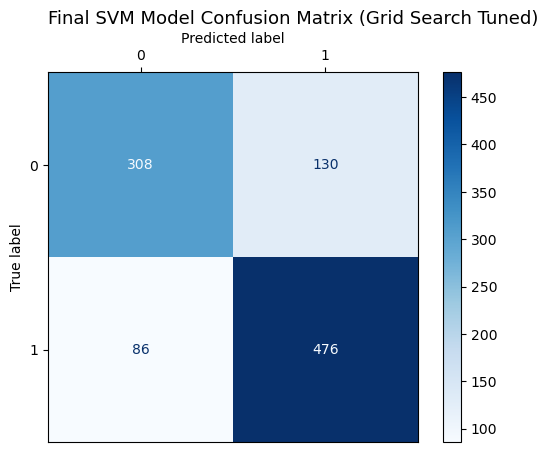

In [16]:
chosen = candidate_models[best_stage_name]

if isinstance(chosen, tuple):
    inner_pipeline, final_threshold = chosen
    inner_pipeline.fit(X_train_raw, y_train)
    final_model_to_save = ThresholdedClassifier(inner_pipeline, threshold=final_threshold)
    final_model_to_save.classes_ = inner_pipeline.classes_
    final_pred = final_model_to_save.predict(X_test_raw)
    print(f"Final model is '{best_stage_name}' with a custom threshold of {final_threshold:.4f}")
else:
    final_pipeline = chosen
    final_pipeline.fit(X_train_raw, y_train)
    final_pred = final_pipeline.predict(X_test_raw)
    final_model_to_save = final_pipeline
    
test_accuracy = log_test(f"FINAL: {best_stage_name}", y_test, final_pred)
print(classification_report(y_test, final_pred))

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, cmap="Blues")
plt.title(f"Final SVM Model Confusion Matrix ({best_stage_name})", fontsize=13, loc='left')
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)
plt.show()

**Important note for `app.py`:** the saved model below is a full `Pipeline` (feature selection + scaling + classifier combined), not a bare classifier. Any manual scaling/feature-selection currently done in `app.py` should be **removed** — pass the full raw feature row directly to `final_model.predict()` and let the pipeline handle the rest internally.

## Permutation Importance 

In [17]:
# Run permutation importance on the test set using the fitted pipeline
pi_result = permutation_importance(
    final_model_to_save, 
    X_test_raw, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)

# Sort and display feature importances
sorted_importances_idx = pi_result.importances_mean.argsort()[::-1]
for i in sorted_importances_idx:
    print(f"{X_test_raw.columns[i]:<30}: {pi_result.importances_mean[i]:.4f} +/- {pi_result.importances_std[i]:.4f}")

cp_atypical angina            : 0.0333 +/- 0.0086
cp_non-anginal                : 0.0146 +/- 0.0047
chol_category_missing         : 0.0105 +/- 0.0025
restecg_st-t abnormality      : 0.0105 +/- 0.0030
sex_Male                      : 0.0095 +/- 0.0060
oldpeak                       : 0.0076 +/- 0.0052
fbs_True                      : 0.0076 +/- 0.0028
thal_normal                   : 0.0065 +/- 0.0049
fbs_missing                   : 0.0061 +/- 0.0029
oldpeak_x_flat_slope          : 0.0056 +/- 0.0035
slope_upsloping               : 0.0047 +/- 0.0035
ca_was_missing                : 0.0046 +/- 0.0048
exang_True                    : 0.0044 +/- 0.0047
trestbps                      : 0.0040 +/- 0.0027
bp_age_ratio                  : 0.0036 +/- 0.0025
slope_flat                    : 0.0030 +/- 0.0031
age_group_40-50               : 0.0026 +/- 0.0025
data_was_missing              : 0.0021 +/- 0.0022
thal_reversable defect        : 0.0014 +/- 0.0016
age_group_50-60               : 0.0013 +/- 0.0021


## 9. Full Accuracy Progression Log

In [18]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy,Type
0,Baseline (default SVC),0.800298,CV (train only)
1,Grid Search Tuned,0.800793,CV (train only)
2,Grid Search + Youden's J,0.800050,CV (train only)
3,Balanced Class Weighting,0.794792,CV (train only)
4,Probability Calibration (sigmoid),0.795793,CV (train only)
5,Kernel Comparison: linear,0.773763,CV (train only)
6,Kernel Comparison: rbf,0.800298,CV (train only)
7,Kernel Comparison: poly,0.800793,CV (train only)
8,FINAL: Grid Search Tuned,0.784000,"TEST (final, touched once)"


In [19]:
# save the trained model
try:
    joblib.dump(final_model_to_save, 'svm_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print(f"Model saved successfully! ('{best_stage_name}', test accuracy = {test_accuracy:.4f})")

Model saved successfully! ('Grid Search Tuned', test accuracy = 0.7840)
